# Wound Detection Model Training

Train a binary classifier using your snakebite wound images as positive class and augmented versions as negative class.

In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


## Step 1: Load Snakebite Images

In [2]:
# Path to your snakebite images
SNAKEBITE_DIR = "C:\\Users\\black\\OneDrive\\Documents\\project\\wound_training_data\\SnakeWounds"
OUTPUT_DIR = "./wound_model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
VALIDATION_SPLIT = 0.2

# Load snakebite images
snakebite_images = []
valid_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

print(f"Loading snakebite images from {SNAKEBITE_DIR}...")
for img_file in tqdm(os.listdir(SNAKEBITE_DIR)):
    if Path(img_file).suffix.lower() in valid_extensions:
        img_path = os.path.join(SNAKEBITE_DIR, img_file)
        try:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMAGE_SIZE)
                snakebite_images.append(img)
        except Exception as e:
            print(f"Error loading {img_file}: {e}")

snakebite_images = np.array(snakebite_images, dtype=np.float32) / 255.0
print(f"Loaded {len(snakebite_images)} snakebite images. Shape: {snakebite_images.shape}")

Loading snakebite images from C:\Users\black\OneDrive\Documents\project\wound_training_data\SnakeWounds...


100%|██████████| 974/974 [00:04<00:00, 225.69it/s]


Loaded 974 snakebite images. Shape: (974, 224, 224, 3)


## Step 2: Generate Synthetic Negative Class (Normal Wounds via Augmentation)

In [3]:
# Create augmented versions as fake "normal wounds"
# This uses your actual snakebite images but heavily augmented to create a distinct negative class
print("\nGenerating augmented negative class...")

augmentor = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

negative_images = []
# Generate ~450-500 augmented images to match positive class
target_negative_count = min(500, len(snakebite_images) + 200)

for orig_img in snakebite_images:
    # Generate 1-2 augmented versions per original image
    for _ in range(2):
        augmented = augmentor.random_transform(orig_img)
        negative_images.append(augmented)
        if len(negative_images) >= target_negative_count:
            break
    if len(negative_images) >= target_negative_count:
        break

negative_images = np.array(negative_images[:target_negative_count], dtype=np.float32)
print(f"Generated {len(negative_images)} augmented negative samples. Shape: {negative_images.shape}")


Generating augmented negative class...
Generated 500 augmented negative samples. Shape: (500, 224, 224, 3)


## Step 3: Prepare Dataset (Positive + Negative Labels)

In [4]:
# Combine positive (snakebite) and negative (augmented) classes
print("\nPreparing dataset...")

X = np.vstack([snakebite_images, negative_images])
y = np.hstack([
    np.ones(len(snakebite_images)),      # 1 = snakebite
    np.zeros(len(negative_images))       # 0 = normal wound
])

print(f"Total dataset: {len(X)} images")
print(f"  - Snakebite (positive): {np.sum(y == 1)}")
print(f"  - Normal wounds (negative): {np.sum(y == 0)}")
print(f"  - Class balance: {np.sum(y == 1) / len(y) * 100:.1f}% positive")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {len(X_train)} images")
print(f"Test set: {len(X_test)} images")


Preparing dataset...
Total dataset: 1474 images
  - Snakebite (positive): 974
  - Normal wounds (negative): 500
  - Class balance: 66.1% positive

Train set: 1179 images
Test set: 295 images


## Step 4: Build Transfer Learning Model

In [5]:
print("\nBuilding model...")

# Load pretrained ResNet50 (ImageNet weights)
base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze base model weights (transfer learning)
base_model.trainable = False

# Add custom layers for binary classification
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

model = Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print(model.summary())


Building model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


## Step 5: Train Model

In [6]:
print("\nTraining model...")

# Data augmentation for training
train_augmentor = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

# Train with augmentation
history = model.fit(
    train_augmentor.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")


Training model...


c:\Users\black\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5943 - auc: 0.4988 - loss: 0.7174 - val_accuracy: 0.6610 - val_auc: 0.5150 - val_loss: 0.6534 - learning_rate: 1.0000e-04
Epoch 2/20
 1/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6562 - auc: 0.4705 - loss: 0.7131

c:\Users\black\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - accuracy: 0.6562 - auc: 0.4705 - loss: 0.7131 - val_accuracy: 0.6610 - val_auc: 0.5276 - val_loss: 0.6530 - learning_rate: 1.0000e-04
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6513 - auc: 0.4826 - loss: 0.6736 - val_accuracy: 0.6610 - val_auc: 0.5122 - val_loss: 0.6408 - learning_rate: 1.0000e-04
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step - accuracy: 0.5625 - auc: 0.3917 - loss: 0.7365 - val_accuracy: 0.6610 - val_auc: 0.5203 - val_loss: 0.6410 - learning_rate: 1.0000e-04
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.6162 - auc: 0.5171 - loss: 0.6697 - val_accuracy: 0.6610 - val_auc: 0.5321 - val_loss: 0.6430 - learning_rate: 1.0000e-04
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 261ms/step - accuracy: 0.7500 - auc: 0.7286 - loss: 0.5118 - val_accuracy: 0.6610 - val_auc: 0.5412 - val_loss: 0.6432 - learning_rate: 5.0000e-05

Training complete!


## Step 6: Evaluate Model


Evaluating model on test set...
Test Loss: 0.6408
Test Accuracy: 0.6610 (66.10%)
Test AUC: 0.5122


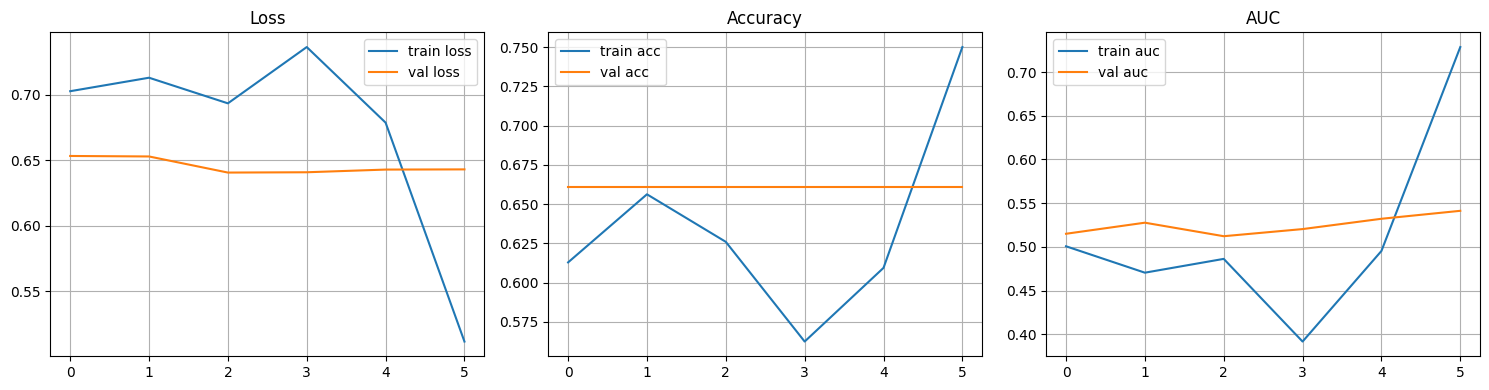


Training plot saved to ./wound_model_output/training_history.png


In [7]:
print("\nEvaluating model on test set...")

test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test AUC: {test_auc:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='train acc')
axes[1].plot(history.history['val_accuracy'], label='val acc')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history.history['auc'], label='train auc')
axes[2].plot(history.history['val_auc'], label='val auc')
axes[2].set_title('AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"\nTraining plot saved to {OUTPUT_DIR}/training_history.png")

## Step 7: Fine-tune (Optional - Train Last Layers)

In [8]:
# Unfreeze last few layers of base model for fine-tuning
print("\nFine-tuning: unfreezing last layers...")

base_model.trainable = True
for layer in base_model.layers[:-10]:  # Keep early layers frozen
    layer.trainable = False

# Compile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

# Fine-tune for a few epochs
history_ft = model.fit(
    train_augmentor.flow(X_train, y_train, batch_size=16),
    epochs=5,
    steps_per_epoch=len(X_train) // 16,
    validation_data=(X_test, y_test),
    verbose=1
)

# Re-evaluate
test_loss_ft, test_accuracy_ft, test_auc_ft = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAfter fine-tuning:")
print(f"Test Accuracy: {test_accuracy_ft:.4f} ({test_accuracy_ft*100:.2f}%)")
print(f"Test AUC: {test_auc_ft:.4f}")


Fine-tuning: unfreezing last layers...
Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 60s 748ms/step - accuracy: 0.6537 - auc_1: 0.4961 - loss: 0.6489 - val_accuracy: 0.6610 - val_auc_1: 0.5274 - val_loss: 0.6416
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - accuracy: 0.6875 - auc_1: 0.2308 - loss: 0.6511 - val_accuracy: 0.6610 - val_auc_1: 0.5241 - val_loss: 0.6417
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 53s 724ms/step - accuracy: 0.6452 - auc_1: 0.4985 - loss: 0.6567 - val_accuracy: 0.6610 - val_auc_1: 0.5495 - val_loss: 0.6537
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.6875 - auc_1: 0.8455 - loss: 0.5449 - val_accuracy: 0.6610 - val_auc_1: 0.5539 - val_loss: 0.6540
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 54s 739ms/step - accuracy: 0.6512 - auc_1: 0.5179 - loss: 0.6509 - val_accuracy: 0.6610 - val_auc_1: 0.5681 - val_loss: 0.6739

After fine-tuning:
Test Accuracy: 0.6610 (66.10%)
Test AUC: 0.5681


## Step 8: Save Model

In [9]:
print("\nSaving model...")

model_path = os.path.join(OUTPUT_DIR, 'wound_classifier.h5')
model.save(model_path, save_format='h5')

print(f"Model saved to: {model_path}")
print(f"Model size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

# Save metadata
metadata = {
    'model_type': 'wound_classifier',
    'framework': 'tensorflow',
    'input_shape': [224, 224, 3],
    'output_shape': [1],
    'classes': {
        0: 'not_snakebite',
        1: 'snakebite'
    },
    'test_accuracy': float(test_accuracy_ft),
    'test_auc': float(test_auc_ft),
    'threshold': 0.5
}

import json
metadata_path = os.path.join(OUTPUT_DIR, 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {metadata_path}")
print(f"\nMetadata:\n{json.dumps(metadata, indent=2)}")


Saving model...
Model saved to: ./wound_model_output\wound_classifier.h5
Model size: 130.83 MB
Metadata saved to: ./wound_model_output\model_metadata.json

Metadata:
{
  "model_type": "wound_classifier",
  "framework": "tensorflow",
  "input_shape": [
    224,
    224,
    3
  ],
  "output_shape": [
    1
  ],
  "classes": {
    "0": "not_snakebite",
    "1": "snakebite"
  },
  "test_accuracy": 0.6610169410705566,
  "test_auc": 0.568128228187561,
  "threshold": 0.5
}


## Step 9: Test Predictions

In [10]:
print("\nTesting predictions on a few samples...")

# Sample predictions
test_samples = X_test[:5]
predictions = model.predict(test_samples)

for i, (sample, pred) in enumerate(zip(test_samples, predictions)):
    is_snakebite = pred[0] > 0.5
    confidence = pred[0] if is_snakebite else (1 - pred[0])
    print(f"Sample {i+1}: {'SNAKEBITE' if is_snakebite else 'NORMAL'} (confidence: {confidence:.2%})")

print("\n✓ Model training complete! Ready for deployment to Cloud Run.")


Testing predictions on a few samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Sample 1: SNAKEBITE (confidence: 77.65%)
Sample 2: SNAKEBITE (confidence: 76.57%)
Sample 3: SNAKEBITE (confidence: 77.53%)
Sample 4: SNAKEBITE (confidence: 78.34%)
Sample 5: SNAKEBITE (confidence: 77.59%)

✓ Model training complete! Ready for deployment to Cloud Run.


## Next Steps:

1. Copy `wound_classifier.h5` to your `model/` directory
2. Update `model/server.py` to add `/predict/wound` endpoint
3. Rebuild and redeploy to Cloud Run
4. Test via the frontend diagnose page